# Part A — EDA and Missing Values

**Project:** Academy Nova Course Cancellation Prediction  
**Group:** 51  
**Main metric:** ROC-AUC  

This notebook covers the first project section: exploratory data analysis and missing-value analysis.

The goal of this stage is to understand the dataset before modeling, identify meaningful patterns, detect data-quality issues, compare train and test distributions, and decide how missing values should be handled.

Important project principles:
- The test set must never be used for fitting preprocessing steps.
- Every visualization should have a purpose.
- EDA conclusions should directly support feature engineering and modeling decisions.
- Missing-value treatment should be justified using the data and business logic.

In [345]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.feature_selection import mutual_info_classif

# Make project src importable from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import ID_COL, TARGET_COL, RANDOM_STATE
from src.data_loading import load_raw_data, validate_raw_data

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE

42

## 1. Load and Validate the Raw Data

Before starting EDA, we validate the basic structure of the train and test datasets.  
This prevents common project mistakes such as using the wrong file, accidentally fitting on the test target, duplicate IDs, or column mismatches between train and test.

In [346]:
train_df, test_df = load_raw_data()
validate_raw_data(train_df, test_df)

Validating raw data...
Raw data validation passed.
Train shape: (63464, 29)
Test shape: (15866, 28)
Target positive rate: 0.4144


## 2. Dataset Overview

We first inspect the dataset dimensions, column types, and the role of each column.  
This gives us a map of the problem before deeper analysis.

In [347]:
overview = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.astype(str).values,
    "missing_count": train_df.isna().sum().values,
    "missing_pct": (train_df.isna().mean().values * 100).round(2),
    "unique_values": train_df.nunique(dropna=True).values
})

overview

,column,dtype,missing_count,missing_pct,unique_values
0,Client_ID,int64,0,0.00,63464
1,Professionals_Count,int64,0,0.00,5
2,Students_Count,float64,4,0.01,5
3,Observers_Count,int64,0,0.00,5
4,Course_Start_Date,object,0,0.00,666
5,Practical_Hours,int64,0,0.00,18
6,Theory_Hours,int64,0,0.00,29
7,Registration_Days_Before,float64,2666,4.20,423
8,Origin_Country,object,557,0.88,721
9,Catering_Package,object,407,0.64,321


In [348]:
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

numeric_features = [col for col in numeric_cols if col not in [ID_COL, TARGET_COL]]
categorical_features = categorical_cols.copy()

print(f"Number of rows in train: {train_df.shape[0]}")
print(f"Number of rows in test: {test_df.shape[0]}")
print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical/date features: {len(categorical_features)}")

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical/date features:")
print(categorical_features)

Number of rows in train: 63464
Number of rows in test: 15866
Number of numeric features: 16
Number of categorical/date features: 11

Numeric features:
['Professionals_Count', 'Students_Count', 'Observers_Count', 'Practical_Hours', 'Theory_Hours', 'Registration_Days_Before', 'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets', 'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes', 'Returning_Client', 'Agent_ID', 'Company_ID', 'Daily_Tuition_Cost']

Categorical/date features:
['Course_Start_Date', 'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms']


### Initial observations

The training set contains 63,464 historical course registrations and the test set contains 15,866 new registrations.  
The target variable is `Dropped_Course`, where 1 means the course registration was cancelled and 0 means it was not cancelled.

The dataset contains a mix of numerical, categorical, ID-like, and date-based variables.  
This means our preprocessing will need to combine several strategies: missing-value handling, categorical encoding, date feature extraction, and possibly special handling for high-missingness ID columns such as `Company_ID` and `Agent_ID`.

## 3. Target Distribution

The target distribution tells us how common course cancellations are.  
This is important because it affects model evaluation: if the classes are imbalanced, accuracy alone may be misleading.  
The project metric is ROC-AUC, which is appropriate because it evaluates the model's ranking ability across thresholds.

In [349]:
target_counts = train_df[TARGET_COL].value_counts().sort_index()
target_pct = train_df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})

target_summary

,count,percentage
Dropped_Course,,
0,37165,58.56
1,26299,41.44


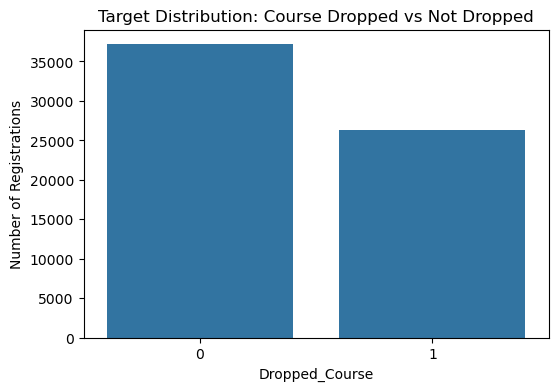

In [350]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x=TARGET_COL)
plt.title("Target Distribution: Course Dropped vs Not Dropped")
plt.xlabel("Dropped_Course")
plt.ylabel("Number of Registrations")
plt.show()

### Target insight

The dataset is not perfectly balanced: approximately 41.4% of registrations were cancelled and 58.6% were not cancelled.  
This is not an extreme imbalance, but it is still important to use ROC-AUC rather than relying only on accuracy.  
For the business problem, we care about ranking registrations by cancellation risk, because the company can prioritize operational intervention for the highest-risk cases.

## 4. Missing-Value Analysis

Missing values are not only a technical issue; they may contain business information.  
For example, a missing `Company_ID` or `Agent_ID` may indicate a different registration process, a less formal client relationship, or incomplete CRM data.  
Therefore, we analyze missingness before deciding how to impute it.

In [351]:
def missing_summary(df, name):
    summary = pd.DataFrame({
        "column": df.columns,
        f"{name}_missing_count": df.isna().sum().values,
        f"{name}_missing_pct": (df.isna().mean().values * 100).round(2),
        f"{name}_non_missing_count": df.notna().sum().values,
    })
    return summary.sort_values(f"{name}_missing_count", ascending=False)

train_missing = missing_summary(train_df, "train")
test_missing = missing_summary(test_df, "test")

train_missing.head(20)

,column,train_missing_count,train_missing_pct,train_non_missing_count
25,Company_ID,60344,95.08,3120
24,Agent_ID,11173,17.61,52291
7,Registration_Days_Before,2666,4.20,60798
11,Requested_Lab_Config,1736,2.74,61728
16,Physical_Course_Kits,1040,1.64,62424
19,Enrollment_Type,719,1.13,62745
22,Submission_Source,605,0.95,62859
26,Payment_Terms,587,0.92,62877
8,Origin_Country,557,0.88,62907
9,Catering_Package,407,0.64,63057


In [352]:
test_missing.head(20)

,column,test_missing_count,test_missing_pct,test_non_missing_count
25,Company_ID,15297,96.41,569
24,Agent_ID,2794,17.61,13072
7,Registration_Days_Before,642,4.05,15224
11,Requested_Lab_Config,477,3.01,15389
16,Physical_Course_Kits,227,1.43,15639
19,Enrollment_Type,177,1.12,15689
8,Origin_Country,160,1.01,15706
22,Submission_Source,149,0.94,15717
26,Payment_Terms,144,0.91,15722
9,Catering_Package,111,0.70,15755


In [353]:
missing_compare = train_missing.merge(
    test_missing,
    on="column",
    how="outer"
).fillna(0)

missing_compare = missing_compare[
    [
        "column",
        "train_missing_count",
        "train_missing_pct",
        "test_missing_count",
        "test_missing_pct",
    ]
].sort_values("train_missing_pct", ascending=False)

missing_compare

,column,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct
5,Company_ID,60344,95.08,15297.0,96.41
0,Agent_ID,11173,17.61,2794.0,17.61
21,Registration_Days_Before,2666,4.20,642.0,4.05
22,Requested_Lab_Config,1736,2.74,477.0,3.01
14,Physical_Course_Kits,1040,1.64,227.0,1.43
9,Enrollment_Type,719,1.13,177.0,1.12
25,Submission_Source,605,0.95,149.0,0.94
13,Payment_Terms,587,0.92,144.0,0.91
12,Origin_Country,557,0.88,160.0,1.01
2,Catering_Package,407,0.64,111.0,0.70


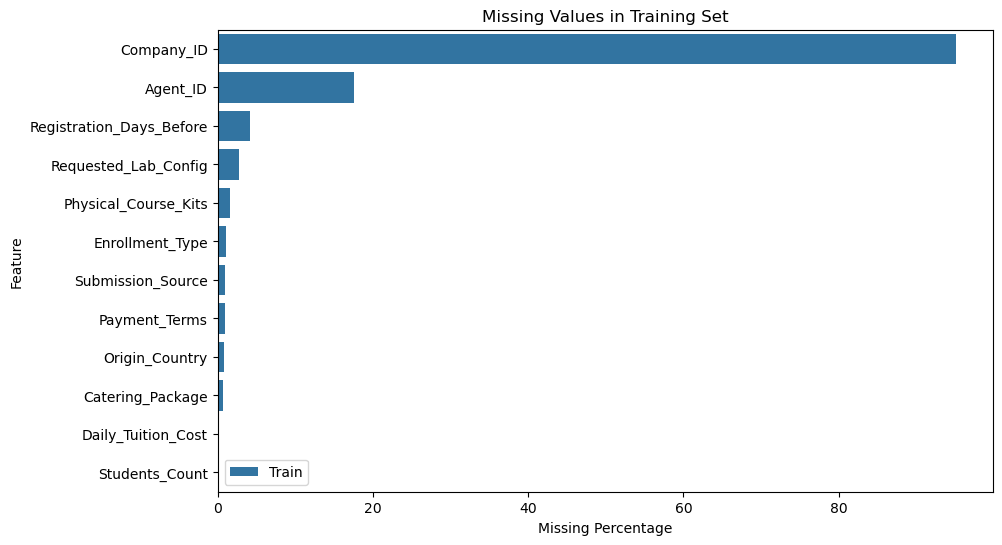

In [354]:
missing_plot_df = missing_compare[
    (missing_compare["train_missing_pct"] > 0) | 
    (missing_compare["test_missing_pct"] > 0)
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_plot_df,
    x="train_missing_pct",
    y="column",
    label="Train"
)
plt.title("Missing Values in Training Set")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.show()

### Missing-value insight

The strongest missingness appears in `Company_ID`, which is missing in most rows, and `Agent_ID`, which is missing in a meaningful minority of rows.  
Several operational fields also contain missing values, including `Registration_Days_Before`, `Requested_Lab_Config`, `Physical_Course_Kits`, `Enrollment_Type`, `Submission_Source`, `Payment_Terms`, `Origin_Country`, `Catering_Package`, `Daily_Tuition_Cost`, and `Students_Count`.

Because missingness may reflect the way the registration was created or managed, we should not blindly delete these rows.  
Instead, we will later create missing-indicator features and use imputation strategies suitable for each feature type.

## 5. Missingness by Target

To check whether missing values are predictive, we compare the cancellation rate between rows where a feature is missing and rows where it is present.

In [355]:
missing_target_rows = []

for col in train_df.columns:
    if col in [ID_COL, TARGET_COL]:
        continue
    
    if train_df[col].isna().sum() > 0:
        temp = train_df.copy()
        temp[f"{col}_is_missing"] = temp[col].isna().astype(int)
        
        rates = temp.groupby(f"{col}_is_missing")[TARGET_COL].agg(["count", "mean"])
        
        missing_rate = rates.loc[1, "mean"] if 1 in rates.index else np.nan
        present_rate = rates.loc[0, "mean"] if 0 in rates.index else np.nan
        
        missing_target_rows.append({
            "feature": col,
            "missing_count": int(train_df[col].isna().sum()),
            "missing_dropout_rate": missing_rate,
            "present_dropout_rate": present_rate,
            "difference": missing_rate - present_rate
        })

missing_target_df = pd.DataFrame(missing_target_rows)
missing_target_df = missing_target_df.sort_values("difference", key=lambda s: s.abs(), ascending=False)

missing_target_df

,feature,missing_count,missing_dropout_rate,present_dropout_rate,difference
0,Students_Count,4,1.000000,0.414355,0.585645
9,Company_ID,60344,0.424848,0.212179,0.212668
11,Daily_Tuition_Cost,79,0.518987,0.414262,0.104725
8,Agent_ID,11173,0.335094,0.431336,-0.096243
10,Payment_Terms,587,0.354344,0.414953,-0.060609
7,Submission_Source,605,0.454545,0.414006,0.040540
3,Catering_Package,407,0.385749,0.414577,-0.028828
5,Physical_Course_Kits,1040,0.393269,0.414744,-0.021475
2,Origin_Country,557,0.432675,0.414231,0.018445
4,Requested_Lab_Config,1736,0.409562,0.414528,-0.004966


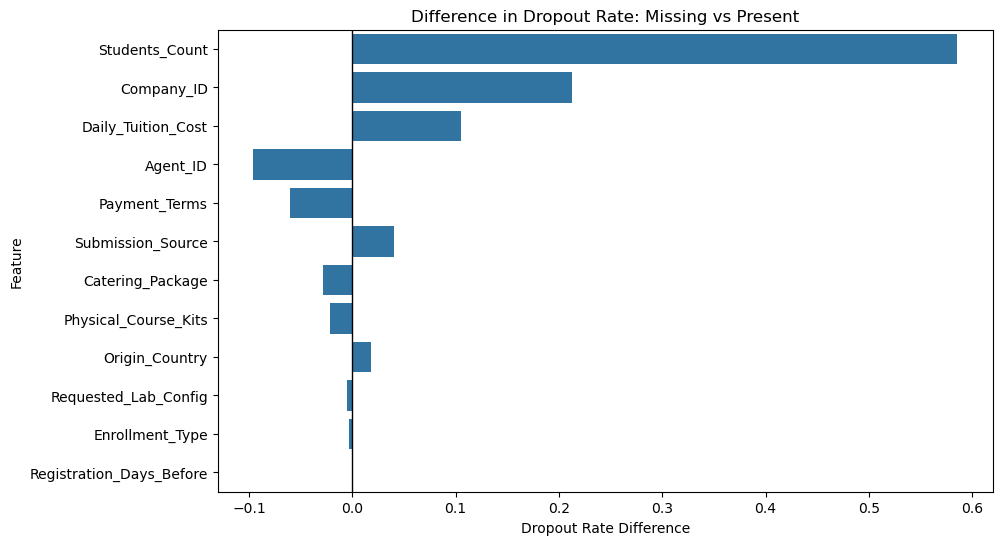

In [356]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_target_df,
    x="difference",
    y="feature"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Difference in Dropout Rate: Missing vs Present")
plt.xlabel("Dropout Rate Difference")
plt.ylabel("Feature")
plt.show()

### Missingness-by-target insight

If a feature has a large dropout-rate difference between missing and non-missing rows, the missingness itself may be informative.  
For these columns, simple imputation alone may hide useful signal.  
Therefore, in feature engineering we will add binary missing indicators for the most important missing columns before applying imputation.

## 6. Numeric Feature Analysis

In this section, we analyze the numerical features.  
The goal is to understand their distributions, detect skewness and outliers, and check how each numerical feature relates to the cancellation target.

This will later guide:
- outlier handling,
- feature transformations,
- feature engineering,
- and model choice.

In [357]:
numeric_features

['Professionals_Count',
 'Students_Count',
 'Observers_Count',
 'Practical_Hours',
 'Theory_Hours',
 'Registration_Days_Before',
 'Prev_Course_Dropouts',
 'Prev_Course_Attended',
 'Pre_Course_Supports_Tickets',
 'Physical_Course_Kits',
 'Waiting_List_Days',
 'Registration_Changes',
 'Returning_Client',
 'Agent_ID',
 'Company_ID',
 'Daily_Tuition_Cost']

In [358]:
numeric_summary = train_df[numeric_features].describe().T

numeric_summary["missing_count"] = train_df[numeric_features].isna().sum()
numeric_summary["missing_pct"] = (train_df[numeric_features].isna().mean() * 100).round(2)
numeric_summary["skewness"] = train_df[numeric_features].skew(numeric_only=True).round(3)

numeric_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct,skewness
Professionals_Count,63464.0,1.835214,0.508607,0.0,2.0,2.0,2.0,4.0,0,0.00,-0.474
Students_Count,63460.0,8.751718,294.238584,0.0,0.0,0.0,0.0,9999.0,4,0.01,33.924
Observers_Count,63464.0,0.005326,0.089662,0.0,0.0,0.0,0.0,10.0,0,0.00,45.379
Practical_Hours,63464.0,6.609054,215.502929,-5.0,0.0,1.0,1.0,10000.0,0,0.00,40.450
Theory_Hours,63464.0,2.164392,1.469854,0.0,1.0,2.0,3.0,41.0,0,0.00,3.354
Registration_Days_Before,60798.0,102.894470,109.178824,0.0,19.0,65.0,150.0,629.0,2666,4.20,1.497
Prev_Course_Dropouts,63464.0,0.095991,0.448526,0.0,0.0,0.0,0.0,21.0,0,0.00,15.704
Prev_Course_Attended,63464.0,0.122967,1.535201,0.0,0.0,0.0,0.0,61.0,0,0.00,21.956
Pre_Course_Supports_Tickets,63464.0,0.513330,0.763563,0.0,0.0,0.0,1.0,5.0,0,0.00,1.466
Physical_Course_Kits,62424.0,0.026224,0.160202,0.0,0.0,0.0,0.0,3.0,1040,1.64,6.000


### Numeric summary insight

The numeric summary helps identify features with different scales, missing values, skewed distributions, and possible outliers.  
Features such as participant counts, registration timing, support tickets, registration changes, and tuition cost may contain useful operational signals about cancellation risk.

Large differences in scale also mean that linear models will require scaling, while tree-based models such as LightGBM/XGBoost are less sensitive to feature scaling.

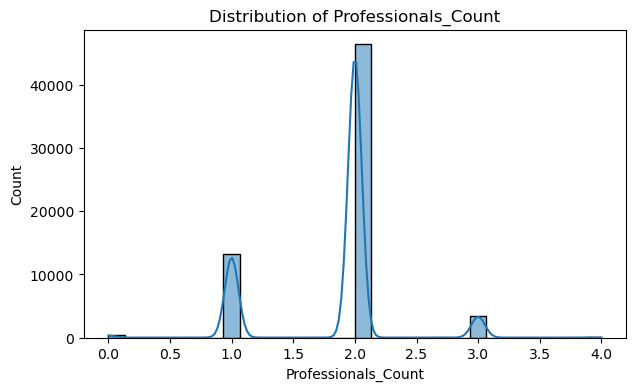

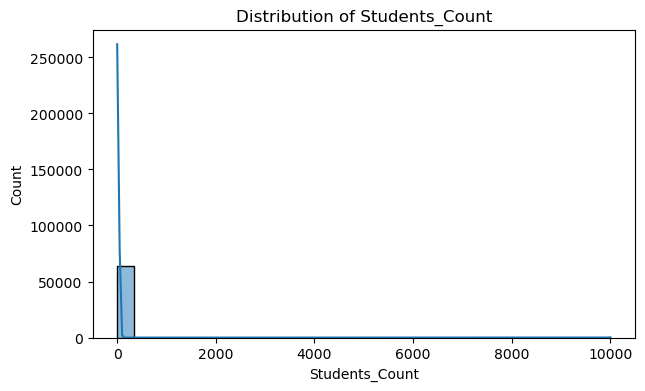

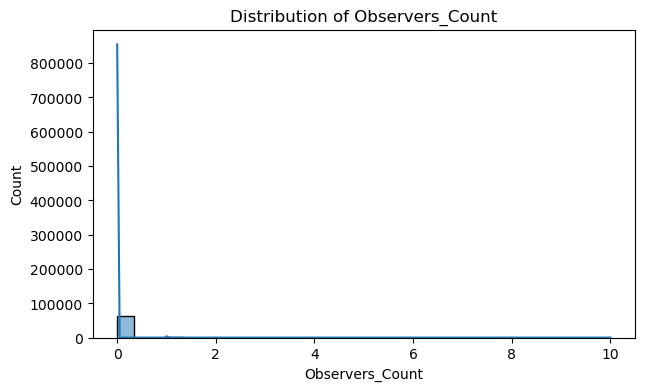

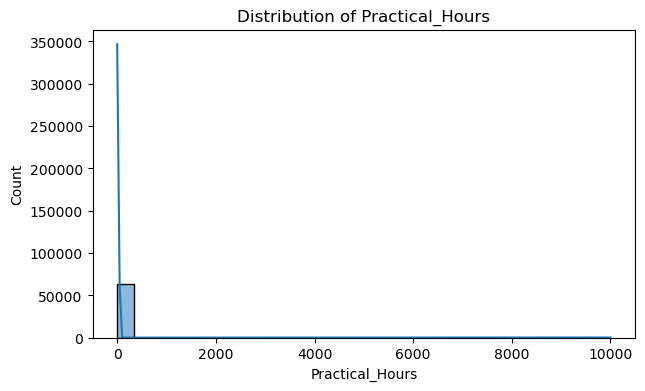

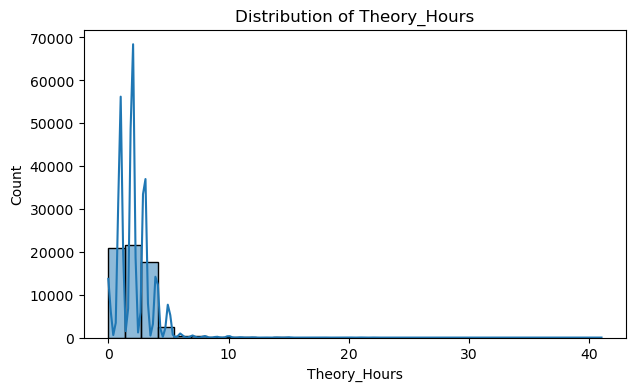

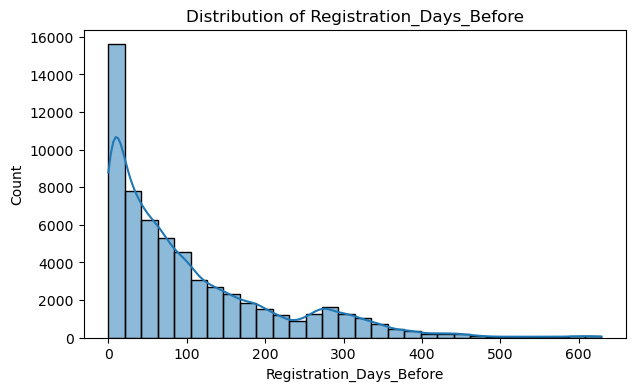

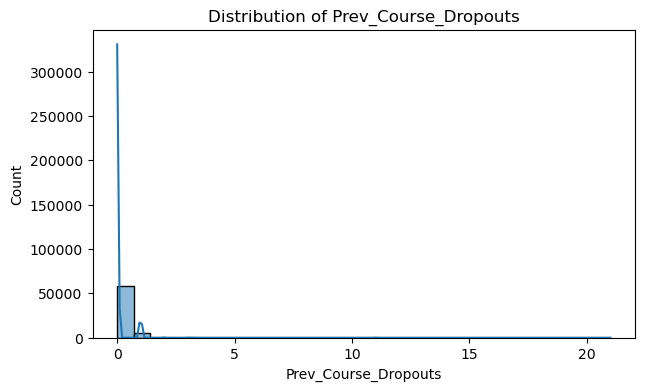

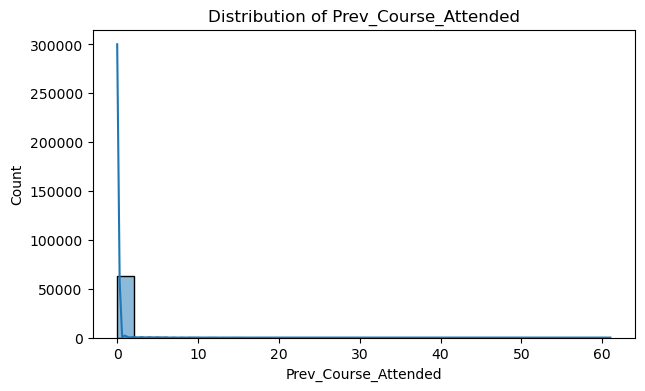

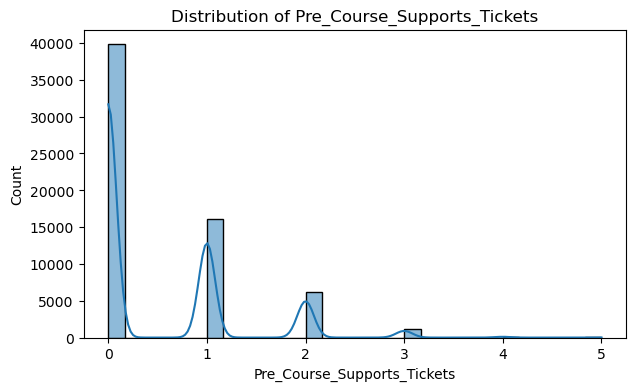

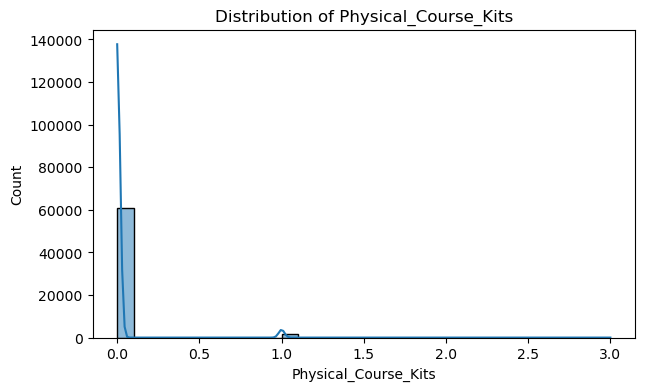

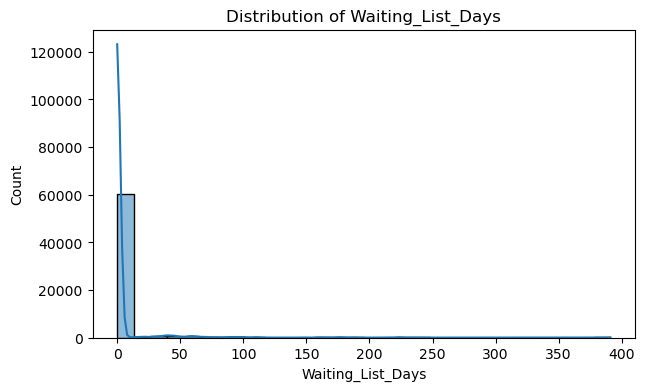

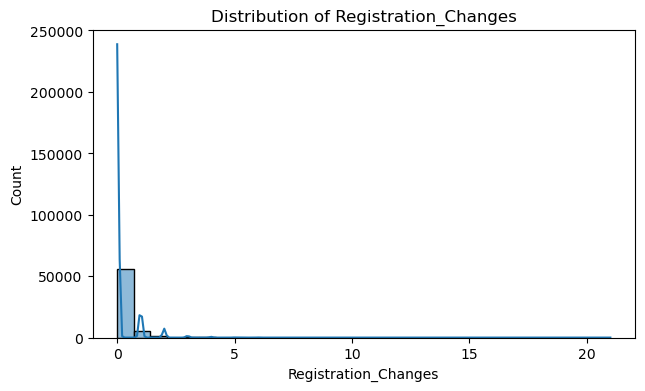

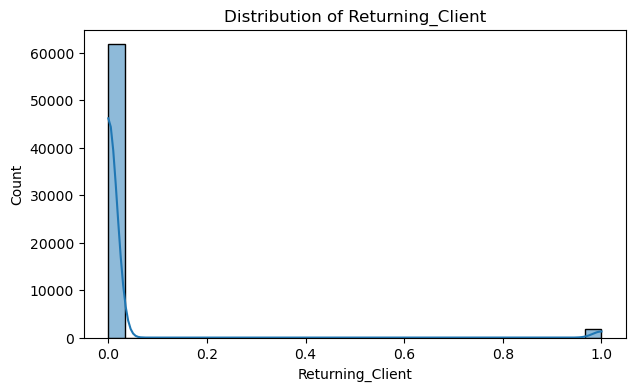

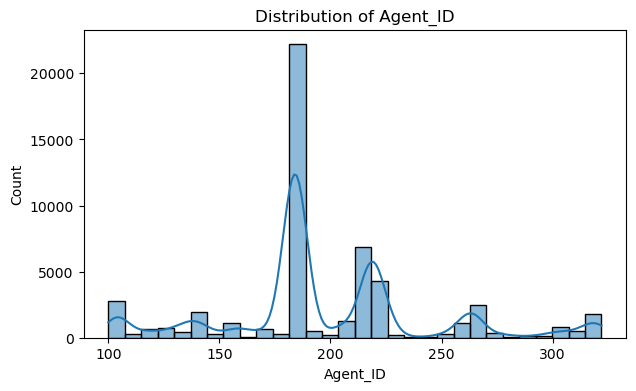

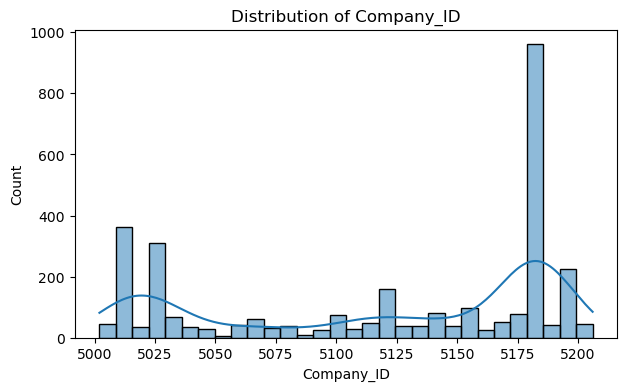

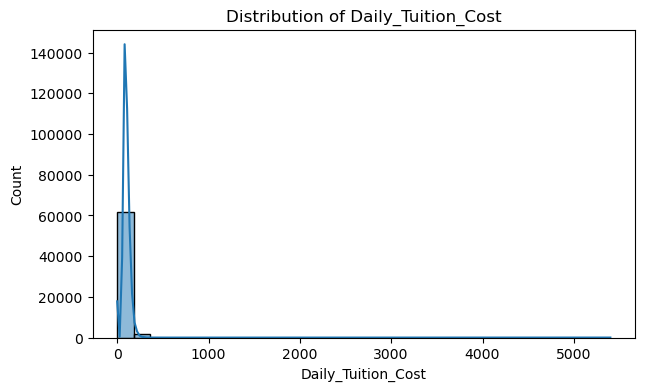

In [359]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(train_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Numerical features by target

We now compare each numerical feature between cancelled and non-cancelled registrations.  
This helps identify features whose distributions differ between the two target classes.

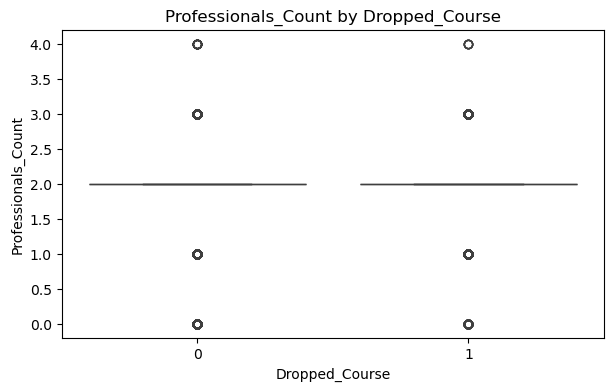

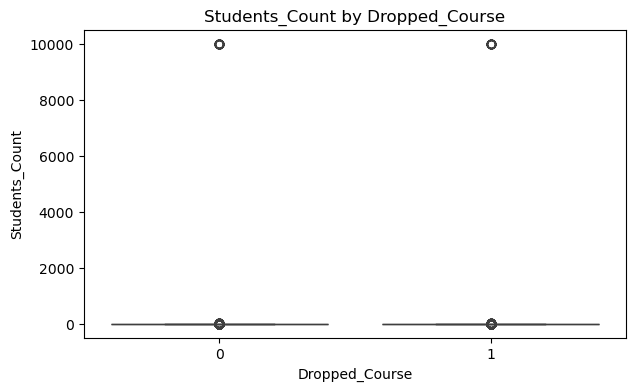

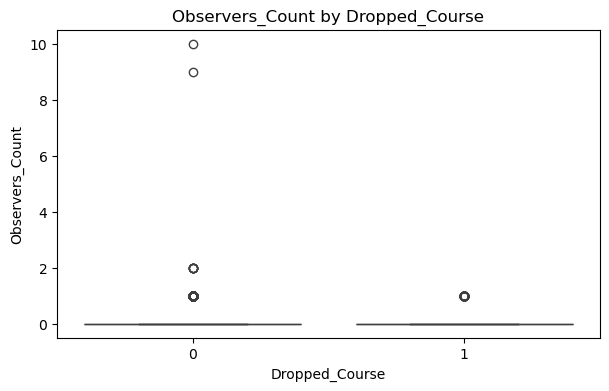

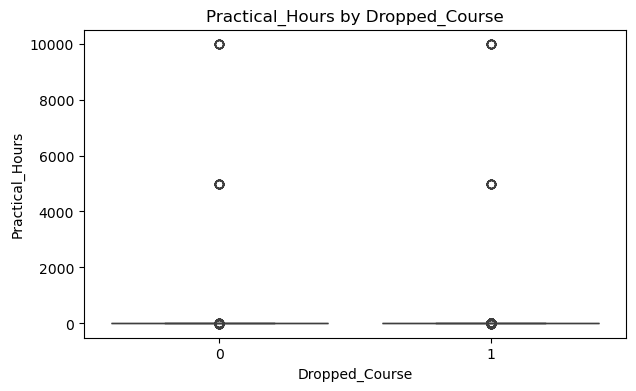

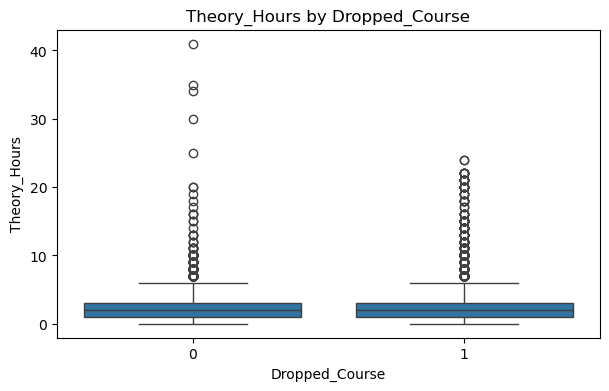

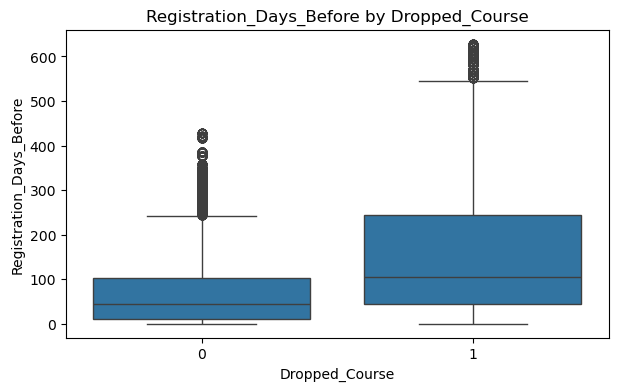

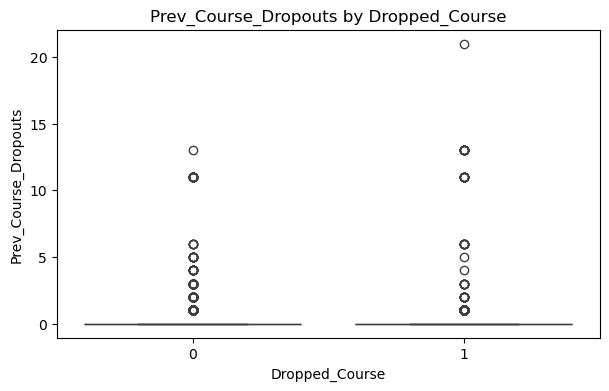

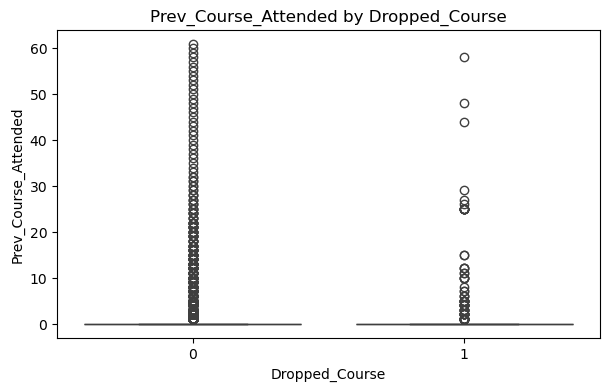

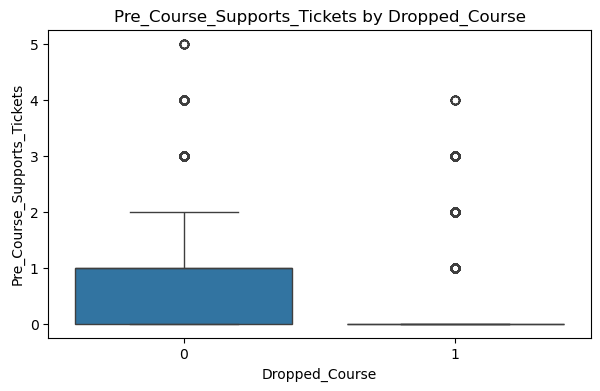

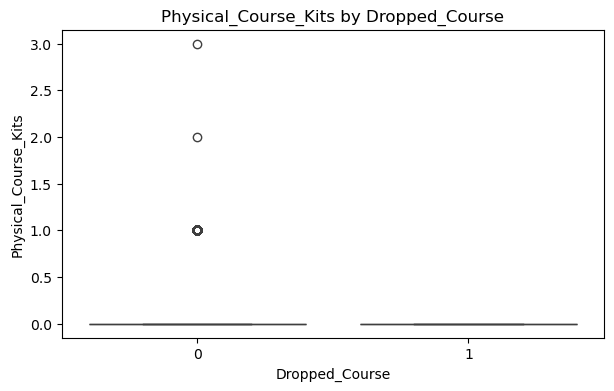

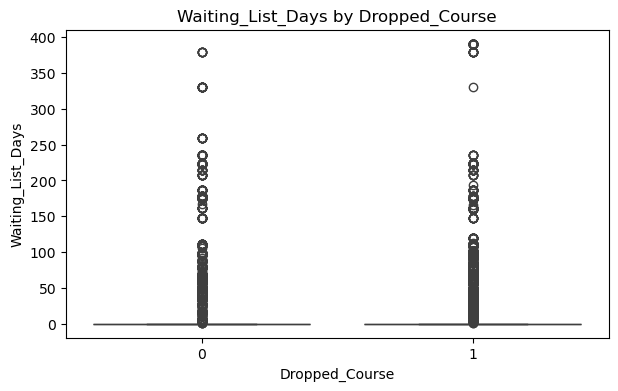

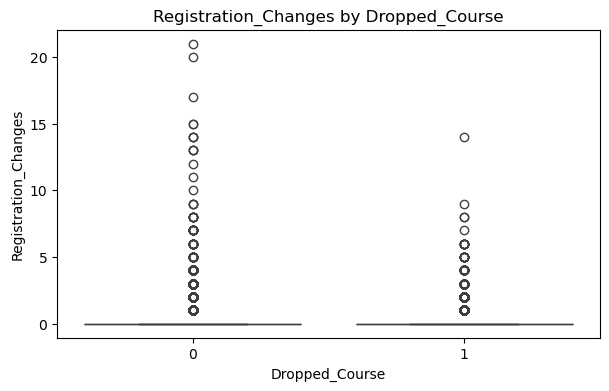

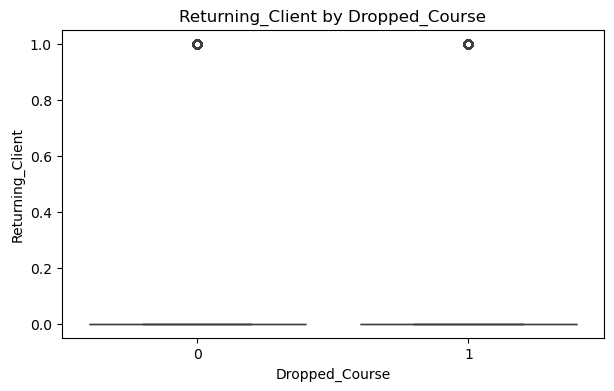

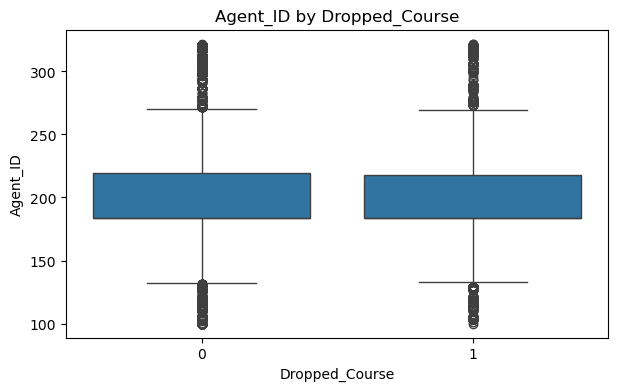

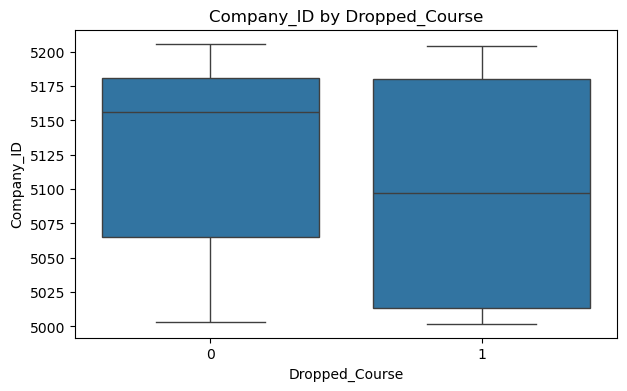

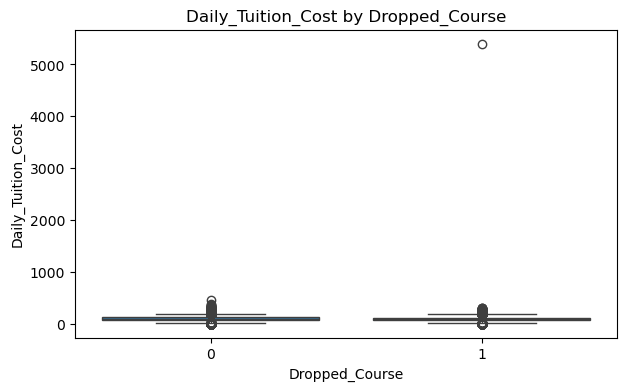

In [360]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train_df, x=TARGET_COL, y=col)
    plt.title(f"{col} by Dropped_Course")
    plt.xlabel("Dropped_Course")
    plt.ylabel(col)
    plt.show()

In [361]:
corr_with_target = (
    train_df[numeric_features + [TARGET_COL]]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_with_target_df = corr_with_target.reset_index()
corr_with_target_df.columns = ["feature", "correlation_with_target"]

corr_with_target_df

,feature,correlation_with_target
0,Registration_Days_Before,0.351210
1,Pre_Course_Supports_Tickets,-0.301284
2,Company_ID,-0.206826
3,Prev_Course_Dropouts,0.199148
4,Registration_Changes,-0.147731
5,Physical_Course_Kits,-0.137800
6,Agent_ID,0.074423
7,Waiting_List_Days,0.067626
8,Returning_Client,-0.059177
9,Professionals_Count,0.056772


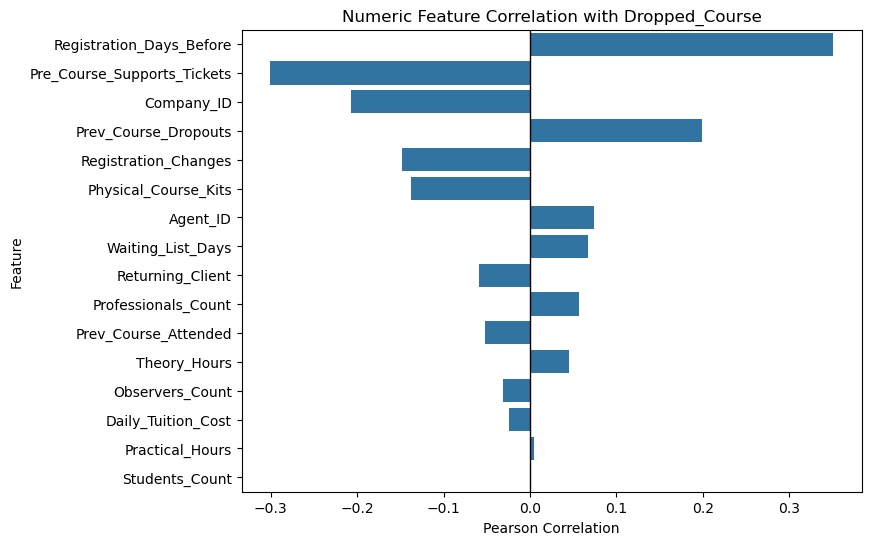

In [362]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=corr_with_target_df,
    x="correlation_with_target",
    y="feature"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Numeric Feature Correlation with Dropped_Course")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.show()

### Correlation insight

Pearson correlation captures only linear relationships, so a low correlation does not mean a feature is useless.  
This is especially important for tree-based models, which can capture nonlinear effects and interactions.

Therefore, correlation is used here as an exploratory tool, not as the only feature-selection criterion.

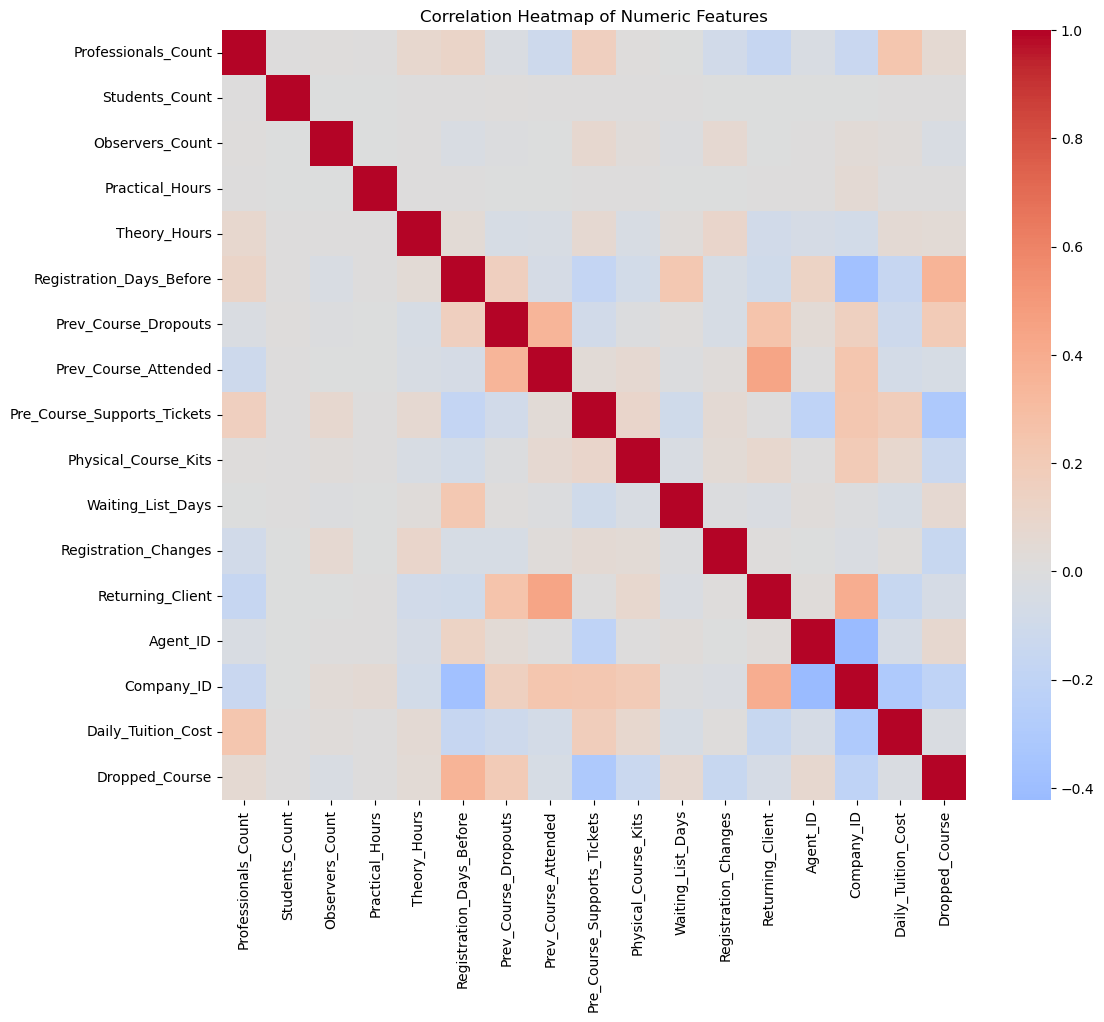

In [363]:
plt.figure(figsize=(12, 10))
corr_matrix = train_df[numeric_features + [TARGET_COL]].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Correlation heatmap insight

The heatmap helps identify redundant or highly related numerical features.  
Highly correlated features are not necessarily harmful for tree-based models, but they may increase noise or variance for some models.  
This will be considered later during feature selection and bias-variance analysis.

## 7. Categorical Feature Analysis

In this section, we analyze the categorical features.  
Categorical variables may contain strong business signals, such as the client segment, registration channel, payment terms, catering package, lab configuration, and country of origin.

The goals of this section are:
- understand the number of unique categories in each feature,
- identify rare categories,
- compare cancellation rate across categories,
- check whether train and test contain different category values,
- and decide how these variables should be encoded later.

In [364]:
categorical_features

['Course_Start_Date',
 'Origin_Country',
 'Catering_Package',
 'Welcome_Gift_Type',
 'Requested_Lab_Config',
 'Assigned_Lab_Config',
 'Enrollment_Type',
 'Lanyard_Color',
 'Client_Category',
 'Submission_Source',
 'Payment_Terms']

In [365]:
categorical_summary_rows = []

for col in categorical_features:
    categorical_summary_rows.append({
        "feature": col,
        "unique_values_train": train_df[col].nunique(dropna=True),
        "unique_values_test": test_df[col].nunique(dropna=True),
        "missing_count_train": train_df[col].isna().sum(),
        "missing_pct_train": round(train_df[col].isna().mean() * 100, 2),
        "missing_count_test": test_df[col].isna().sum(),
        "missing_pct_test": round(test_df[col].isna().mean() * 100, 2),
        "top_train_value": train_df[col].mode(dropna=True).iloc[0] if train_df[col].notna().any() else None,
        "top_test_value": test_df[col].mode(dropna=True).iloc[0] if test_df[col].notna().any() else None,
    })

categorical_summary = pd.DataFrame(categorical_summary_rows)
categorical_summary

,feature,unique_values_train,unique_values_test,missing_count_train,missing_pct_train,missing_count_test,missing_pct_test,top_train_value,top_test_value
0,Course_Start_Date,666,128,0,0.00,0,0.00,2015-10-16,2017-05-19
1,Origin_Country,721,442,557,0.88,160,1.01,PRT,PRT
2,Catering_Package,321,172,407,0.64,111,0.70,Standard (Coffee Only),Standard (Coffee Only)
3,Welcome_Gift_Type,4,4,0,0.00,0,0.00,Branded Notebook,Branded Notebook
4,Requested_Lab_Config,8,8,1736,2.74,477,3.01,Standard PC (Windows),Standard PC (Windows)
5,Assigned_Lab_Config,9,9,0,0.00,0,0.00,Standard PC (Windows),Standard PC (Windows)
6,Enrollment_Type,298,145,719,1.13,177,1.12,General Admission,General Admission
7,Lanyard_Color,240,151,0,0.00,0,0.00,Blue,Blue
8,Client_Category,505,210,0,0.00,0,0.00,SaaS & Software Houses,SaaS & Software Houses
9,Submission_Source,328,164,605,0.95,149,0.94,B2B Platforms & Resellers,B2B Platforms & Resellers


### Categorical summary insight

The categorical features differ greatly in cardinality.  
Some features have only a few categories, such as welcome gift type or lab configuration, while others have many unique values, such as origin country, client category, lanyard color, submission source, payment terms, and course start date.

This matters because low-cardinality variables can usually be handled with one-hot encoding, while high-cardinality variables may require rare-category grouping, frequency encoding, or careful regularization to avoid overfitting.

In [366]:
for col in categorical_features:
    print("=" * 80)
    print(f"Top values for {col}")
    print("=" * 80)
    display(train_df[col].value_counts(dropna=False).head(15).to_frame("train_count"))

Top values for Course_Start_Date


,train_count
Course_Start_Date,
2015-10-16,340
2016-10-13,322
2016-11-07,320
2015-09-18,311
2015-08-14,289
2016-06-17,270
2016-10-28,264
2016-06-24,252
2016-06-15,249


Top values for Origin_Country


,train_count
Origin_Country,
PRT,24256
FRA,6400
DEU,4039
ESP,3564
GBR,3256
ITA,2499
BRA,1287
BEL,1227
NLD,1117


Top values for Catering_Package


...

,train_count
Client_Category,
SaaS & Software Houses,26249
Traditional IT & Telecomm,12916
Big Tech & Multinationals,10643
FinTech & Banking,4160
Industrial Tech & IoT,2346
saas & software houses,674
SAAS & SOFTWARE HOUSES,625
Non-Profit & EduTech,419
TRADITIONAL IT & TELECOMM,337


Top values for Submission_Source


,train_count
Submission_Source,
B2B Platforms & Resellers,48681
Direct Website Registration,4641
Dedicated Sales Team,2552
B2B PLATFORMS & RESELLERS,1236
b2b platforms & resellers,1200
NaN,605
B2B Platforms & Resellers,583
B2B Platforms & Resellers,549
B2B Platforms & Resellers,515


Top values for Payment_Terms


,train_count
Payment_Terms,
Pay Upon Start,46389
Prepaid (Non-Refundable),9638
PAY UPON START,1186
pay upon start,1145
NaN,587
Pay Upon Start,545
Pay Upon Start,530
Pay Upon Start,512
Pay Upon Start,510


### Cancellation rate by category

Next, we calculate the cancellation rate for the most frequent categories in each categorical feature.  
We focus on common categories because very rare categories can have unstable cancellation rates.

In [367]:
def category_target_summary(df, feature, target, min_count=100):
    summary = (
        df.groupby(feature, dropna=False)[target]
        .agg(["count", "mean"])
        .rename(columns={"count": "count", "mean": "dropout_rate"})
        .reset_index()
    )
    
    summary = summary[summary["count"] >= min_count]
    summary = summary.sort_values("dropout_rate", ascending=False)
    return summary


for col in categorical_features:
    print("=" * 80)
    print(f"Cancellation rate by {col}")
    print("=" * 80)
    display(category_target_summary(train_df, col, TARGET_COL, min_count=100).head(15))

Cancellation rate by Course_Start_Date


,Course_Start_Date,count,dropout_rate
160,2015-12-08,177,0.932203
231,2016-02-17,240,0.870833
33,2015-08-03,121,0.818182
94,2015-10-03,125,0.800000
665,2017-04-26,201,0.781095
563,2017-01-14,169,0.775148
581,2017-02-01,118,0.771186
21,2015-07-22,101,0.762376
26,2015-07-27,108,0.759259
205,2016-01-22,108,0.750000


Cancellation rate by Origin_Country


,Origin_Country,count,dropout_rate
707,prt,595,0.677311
89,PRT,280,0.660714
204,PRT,292,0.647260
203,PRT,268,0.638060
583,PRT,24256,0.636255
88,PRT,289,0.615917
317,AGO,286,0.573427
372,CHN,639,0.516432
721,NaN,557,0.432675
627,TUR,185,0.410811


Cancellation rate by Catering_Package


...

,Client_Category,count,dropout_rate
5,Big Tech & Multinationals,120,0.716667
53,Big Tech & Multinationals,123,0.715447
480,big tech & multinationals,277,0.696751
6,Big Tech & Multinationals,127,0.685039
193,Big Tech & Multinationals,10643,0.683454
123,BIG TECH & MULTINATIONALS,275,0.650909
52,Big Tech & Multinationals,149,0.624161
82,Traditional IT & Telecomm,151,0.543046
39,Traditional IT & Telecomm,136,0.463235
396,TRADITIONAL IT & TELECOMM,337,0.456973


Cancellation rate by Submission_Source


,Submission_Source,count,dropout_rate
19,B2B Platforms & Resellers,549,0.460838
328,NaN,605,0.454545
129,B2B PLATFORMS & RESELLERS,1236,0.453074
319,b2b platforms & resellers,1200,0.449167
95,?,185,0.448649
200,B2B Platforms & Resellers,48681,0.446355
20,B2B Platforms & Resellers,500,0.438000
58,B2B Platforms & Resellers,515,0.429126
59,B2B Platforms & Resellers,583,0.425386
308,Unknown,224,0.415179


Cancellation rate by Payment_Terms


,Payment_Terms,count,dropout_rate
25,Prepaid (Non-Refundable),111,1.000000
26,Prepaid (Non-Refundable),104,1.000000
53,Prepaid (Non-Refundable),109,1.000000
207,Prepaid (Non-Refundable),9638,0.997821
234,prepaid (non-refundable),235,0.995745
94,PREPAID (NON-REFUNDABLE),234,0.995726
216,Unknown,214,0.443925
66,?,205,0.404878
236,NaN,587,0.354344
46,Pay Upon Start,512,0.320312


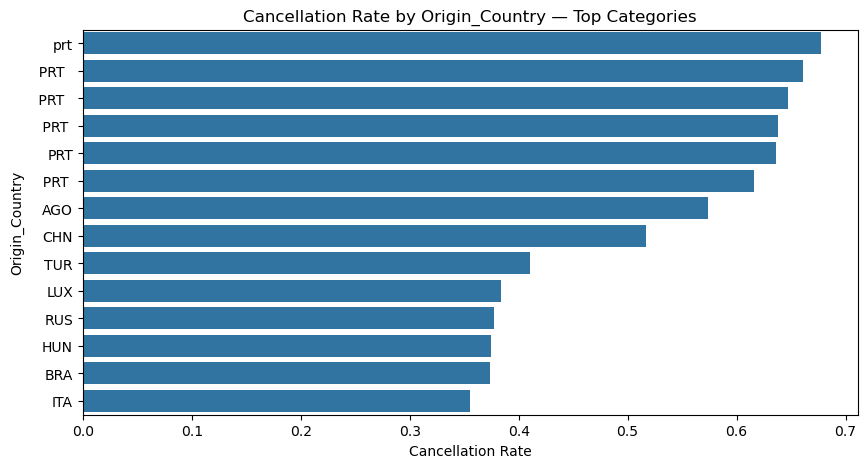

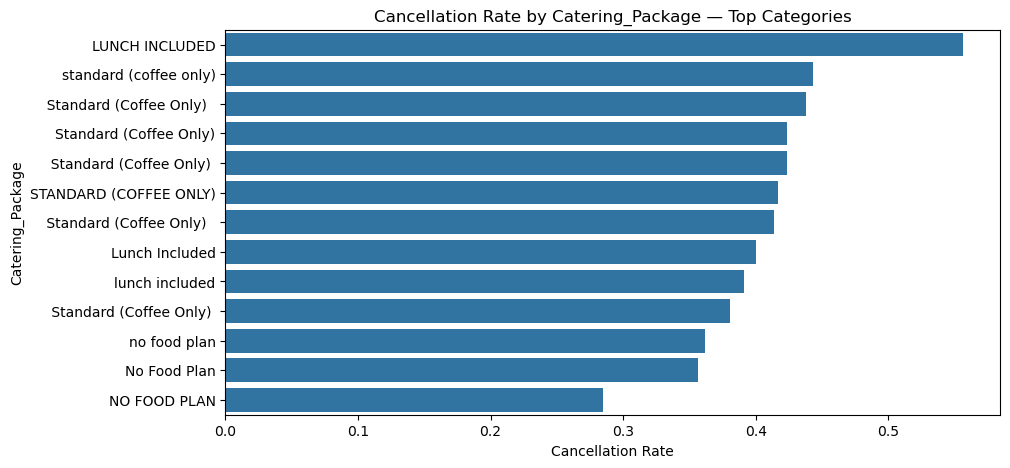

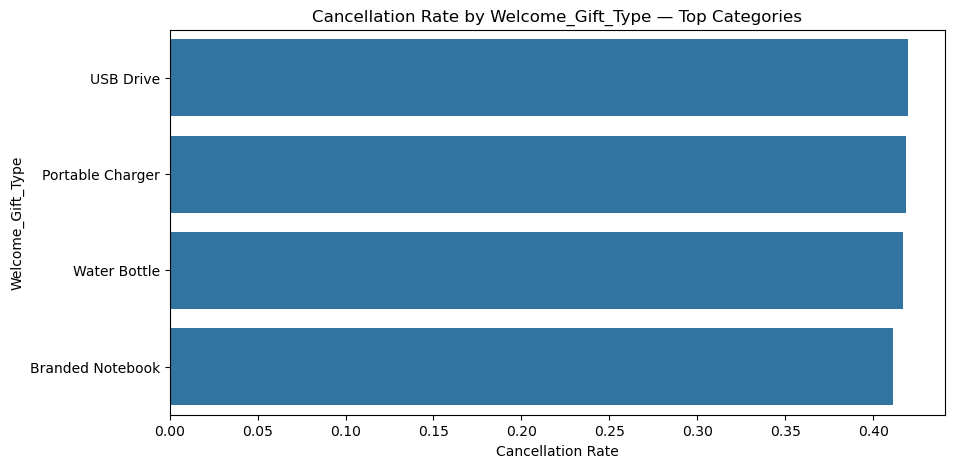

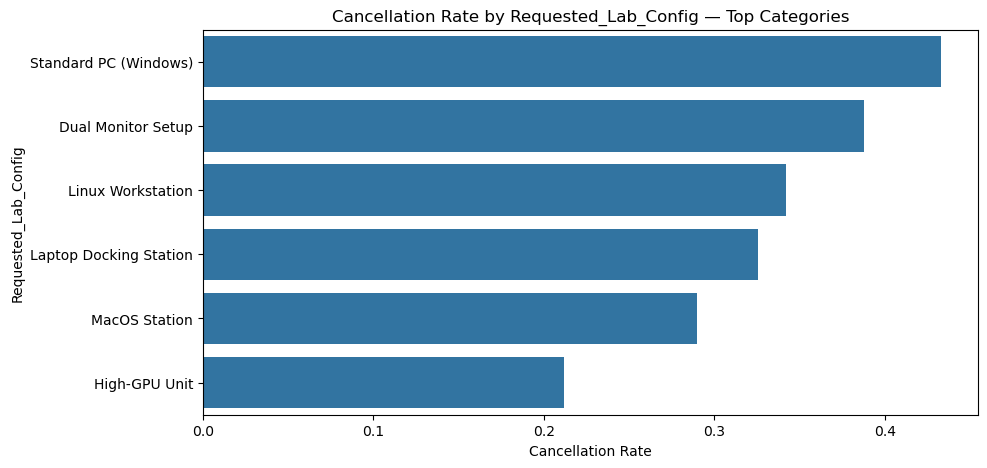

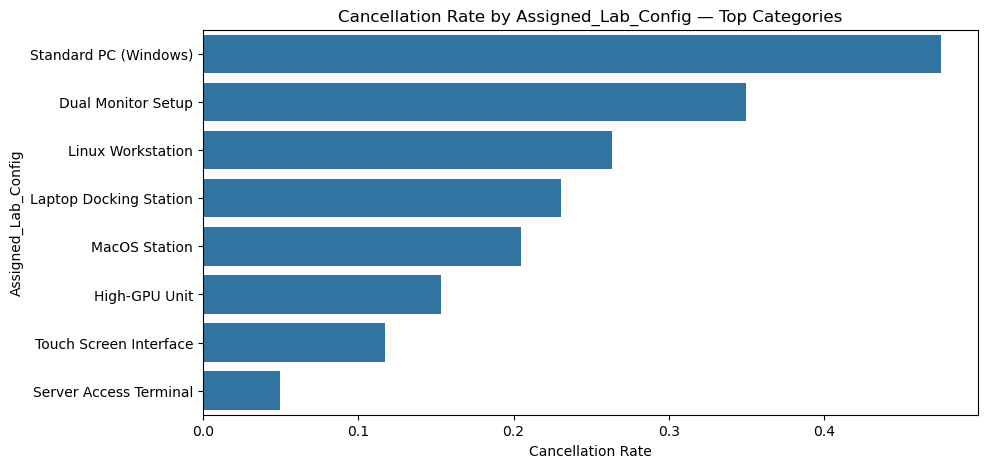

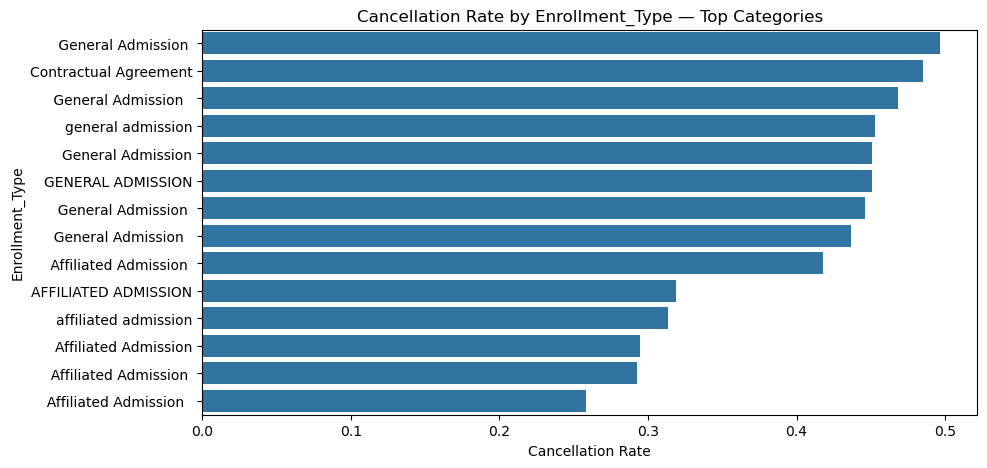

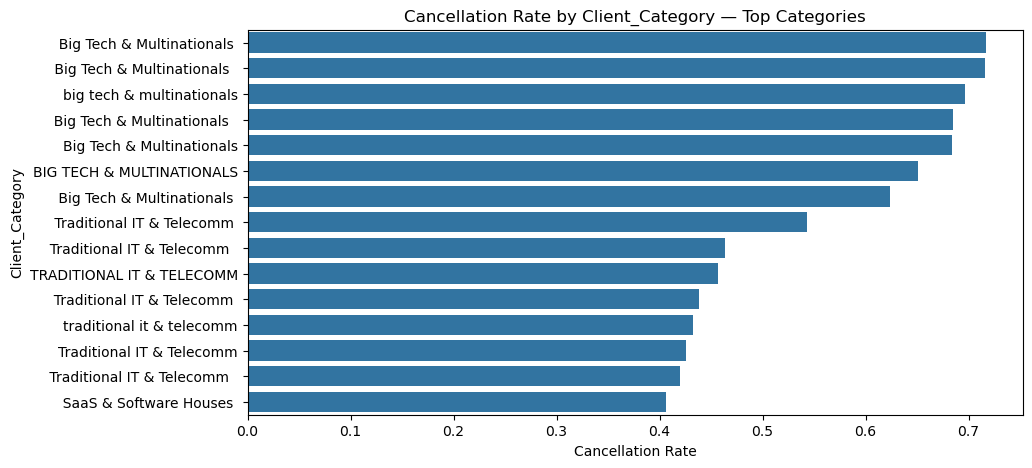

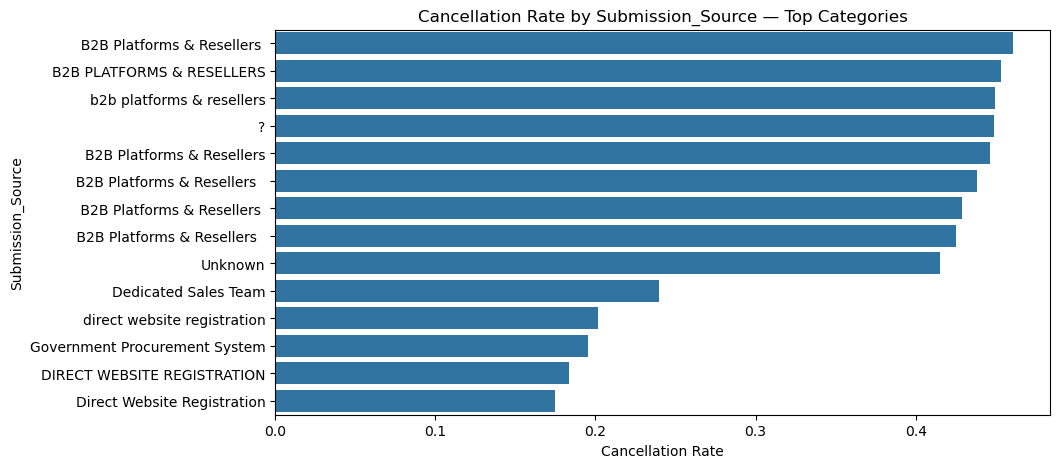

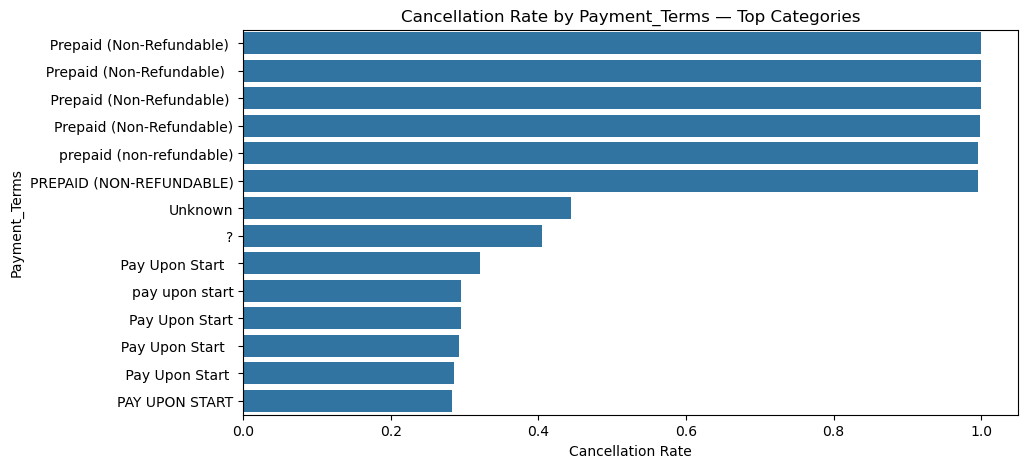

In [368]:
important_categorical_features = [
    "Origin_Country",
    "Catering_Package",
    "Welcome_Gift_Type",
    "Requested_Lab_Config",
    "Assigned_Lab_Config",
    "Enrollment_Type",
    "Client_Category",
    "Submission_Source",
    "Payment_Terms",
]

for col in important_categorical_features:
    if col not in train_df.columns:
        continue
    
    summary = category_target_summary(train_df, col, TARGET_COL, min_count=100).head(15)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=summary,
        x="dropout_rate",
        y=col
    )
    plt.title(f"Cancellation Rate by {col} — Top Categories")
    plt.xlabel("Cancellation Rate")
    plt.ylabel(col)
    plt.show()

### Categorical cancellation-rate insight

The cancellation rate varies across several categorical variables.  
This suggests that categorical features may provide useful predictive signal, especially variables related to client segment, registration source, payment terms, country, and course configuration.

However, category-level cancellation rates must be interpreted carefully.  
Very small categories can produce extreme rates simply because they contain few observations.  
For this reason, the analysis above focuses on categories with at least 100 observations.

### Train/Test category mismatch

Before modeling, we check whether the test set contains categorical values that do not appear in the training set.  
This is important because unseen categories can break naive one-hot encoding unless the encoder is configured to ignore unknown values.

In [369]:
category_mismatch_rows = []

for col in categorical_features:
    train_values = set(train_df[col].dropna().unique())
    test_values = set(test_df[col].dropna().unique())
    
    unseen_in_test = test_values - train_values
    missing_from_test = train_values - test_values
    
    category_mismatch_rows.append({
        "feature": col,
        "train_unique": len(train_values),
        "test_unique": len(test_values),
        "unseen_in_test_count": len(unseen_in_test),
        "train_only_count": len(missing_from_test),
        "unseen_in_test_examples": list(unseen_in_test)[:10],
    })

category_mismatch_df = pd.DataFrame(category_mismatch_rows)
category_mismatch_df.sort_values("unseen_in_test_count", ascending=False)

,feature,train_unique,test_unique,unseen_in_test_count,train_only_count,unseen_in_test_examples
0,Course_Start_Date,666,128,127,665,"[2017-08-12, 2017-05-11, 2017-07-14, 2017-06-0..."
1,Origin_Country,721,442,85,364,"[SLE, IND , #GRC , gbr , U*SA, IR#L, ISR?,..."
9,Submission_Source,328,164,39,203,"[ B2B *Platforms & Resellers , Dedicated Sale..."
8,Client_Category,505,210,37,332,"[ SaaS & Software Hous*es , SaaS & Soft*wa..."
10,Payment_Terms,236,125,28,139,"[ Pay Upon #Start , Prepaid (Non-Ref*undable),..."
2,Catering_Package,321,172,26,175,"[No F!ood Plan, sta#ndard (coffee only), STAND..."
7,Lanyard_Color,240,151,25,114,"[ Red* , Blu?e , Gr*een , BLUE?, RED , ..."
6,Enrollment_Type,298,145,19,172,"[ #General Admission , Gene#ral Admission ..."
3,Welcome_Gift_Type,4,4,0,0,[]
4,Requested_Lab_Config,8,8,0,0,[]


### Train/Test category mismatch insight

If some categorical values appear only in the test set, the preprocessing pipeline must be robust to unknown categories.  
Therefore, when using one-hot encoding later, we will set `handle_unknown="ignore"`.

For high-cardinality categorical variables, we may also group rare categories before encoding in order to reduce dimensionality and improve generalization.

In [370]:
rare_category_rows = []

for col in categorical_features:
    value_counts = train_df[col].value_counts(dropna=False)
    total = len(train_df)
    
    rare_10 = (value_counts < 10).sum()
    rare_50 = (value_counts < 50).sum()
    rare_100 = (value_counts < 100).sum()
    
    rare_category_rows.append({
        "feature": col,
        "unique_values": train_df[col].nunique(dropna=False),
        "rare_categories_count_less_than_10": rare_10,
        "rare_categories_count_less_than_50": rare_50,
        "rare_categories_count_less_than_100": rare_100,
        "most_common_pct": round(value_counts.iloc[0] / total * 100, 2),
    })

rare_category_df = pd.DataFrame(rare_category_rows)
rare_category_df.sort_values("unique_values", ascending=False)

,feature,unique_values,rare_categories_count_less_than_10,rare_categories_count_less_than_50,rare_categories_count_less_than_100,most_common_pct
1,Origin_Country,722,564,666,683,38.22
0,Course_Start_Date,666,11,136,383,0.54
8,Client_Category,505,466,474,478,41.36
9,Submission_Source,329,275,310,314,76.71
2,Catering_Package,322,269,302,308,71.40
6,Enrollment_Type,299,240,280,282,63.90
7,Lanyard_Color,240,169,213,221,49.63
10,Payment_Terms,237,166,220,221,73.09
4,Requested_Lab_Config,9,1,2,2,78.32
5,Assigned_Lab_Config,9,1,1,1,72.37


### Rare category insight

Some categorical variables contain many rare categories.  
Rare categories can increase dimensionality and may cause overfitting, especially when one-hot encoded directly.

In the preprocessing stage, we will consider grouping rare categories into an `"Other"` category or using frequency encoding for high-cardinality features.

## 8. Date Feature Analysis

The dataset contains `Course_Start_Date`, which may capture important time-related patterns.  
Course cancellations may depend on seasonality, month, weekday, holidays, business cycles, or operational planning periods.

In this section, we parse the date column and extract basic time features in order to understand whether cancellation risk changes over time.

In [377]:
date_col = "Course_Start_Date"

train_df[date_col] = pd.to_datetime(train_df[date_col], errors="coerce")
test_df[date_col] = pd.to_datetime(test_df[date_col], errors="coerce")

print("Train date range:")
print(train_df[date_col].min(), "to", train_df[date_col].max())

print("\nTest date range:")
print(test_df[date_col].min(), "to", test_df[date_col].max())

print("\nMissing dates in train:", train_df[date_col].isna().sum())
print("Missing dates in test:", test_df[date_col].isna().sum())

Train date range:
2015-07-01 00:00:00 to 2017-04-26 00:00:00

Test date range:
2017-04-26 00:00:00 to 2017-08-31 00:00:00

Missing dates in train: 0
Missing dates in test: 0


In [378]:
def add_date_eda_features(df, date_col):
    df = df.copy()
    df["Course_Start_Year"] = df[date_col].dt.year
    df["Course_Start_Month"] = df[date_col].dt.month
    df["Course_Start_Quarter"] = df[date_col].dt.quarter
    df["Course_Start_DayOfWeek"] = df[date_col].dt.dayofweek
    df["Course_Start_WeekOfYear"] = df[date_col].dt.isocalendar().week.astype("Int64")
    df["Course_Start_IsWeekend"] = df["Course_Start_DayOfWeek"].isin([5, 6]).astype(int)
    return df

train_date_eda = add_date_eda_features(train_df, date_col)
test_date_eda = add_date_eda_features(test_df, date_col)

train_date_eda[
    [
        date_col,
        "Course_Start_Year",
        "Course_Start_Month",
        "Course_Start_Quarter",
        "Course_Start_DayOfWeek",
        "Course_Start_WeekOfYear",
        "Course_Start_IsWeekend",
    ]
].head()

,Course_Start_Date,Course_Start_Year,Course_Start_Month,Course_Start_Quarter,Course_Start_DayOfWeek,Course_Start_WeekOfYear,Course_Start_IsWeekend
0,2015-07-01,2015,7,3,2,27,0
1,2015-07-01,2015,7,3,2,27,0
2,2015-07-01,2015,7,3,2,27,0
3,2015-07-01,2015,7,3,2,27,0
4,2015-07-01,2015,7,3,2,27,0


In [379]:
monthly_dropout = (
    train_date_eda
    .groupby("Course_Start_Month")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"mean": "dropout_rate"})
    .reset_index()
)

monthly_dropout

,Course_Start_Month,count,dropout_rate
0,1,3736,0.396681
1,2,4965,0.382880
2,3,6458,0.369464
3,4,6825,0.459194
4,5,3676,0.390642
5,6,3923,0.438440
6,7,4529,0.437624
7,8,5858,0.423182
8,9,7400,0.420270
9,10,7605,0.429717


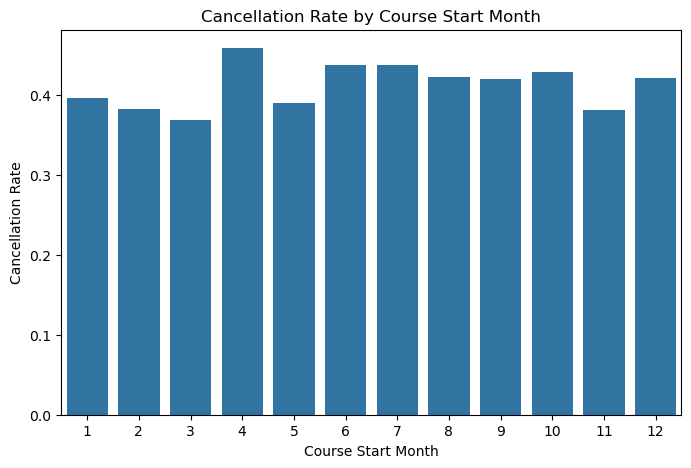

In [380]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=monthly_dropout,
    x="Course_Start_Month",
    y="dropout_rate"
)
plt.title("Cancellation Rate by Course Start Month")
plt.xlabel("Course Start Month")
plt.ylabel("Cancellation Rate")
plt.show()

In [381]:
weekday_dropout = (
    train_date_eda
    .groupby("Course_Start_DayOfWeek")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"mean": "dropout_rate"})
    .reset_index()
)

weekday_dropout["weekday_name"] = weekday_dropout["Course_Start_DayOfWeek"].map({
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
})

weekday_dropout

,Course_Start_DayOfWeek,count,dropout_rate,weekday_name
0,0,9463,0.380112,Monday
1,1,7101,0.374454,Tuesday
2,2,9057,0.405874,Wednesday
3,3,10453,0.494021,Thursday
4,4,11420,0.433975,Friday
5,5,8639,0.431531,Saturday
6,6,7331,0.343609,Sunday


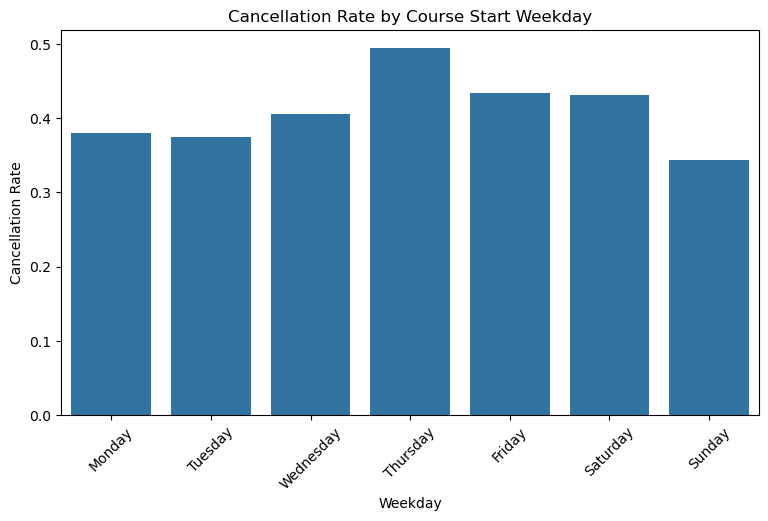

In [382]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=weekday_dropout,
    x="weekday_name",
    y="dropout_rate"
)
plt.title("Cancellation Rate by Course Start Weekday")
plt.xlabel("Weekday")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

### Train/Test date distribution

We compare the date distribution between train and test to check whether the test set represents the same time period as the training set or whether there is a temporal shift.

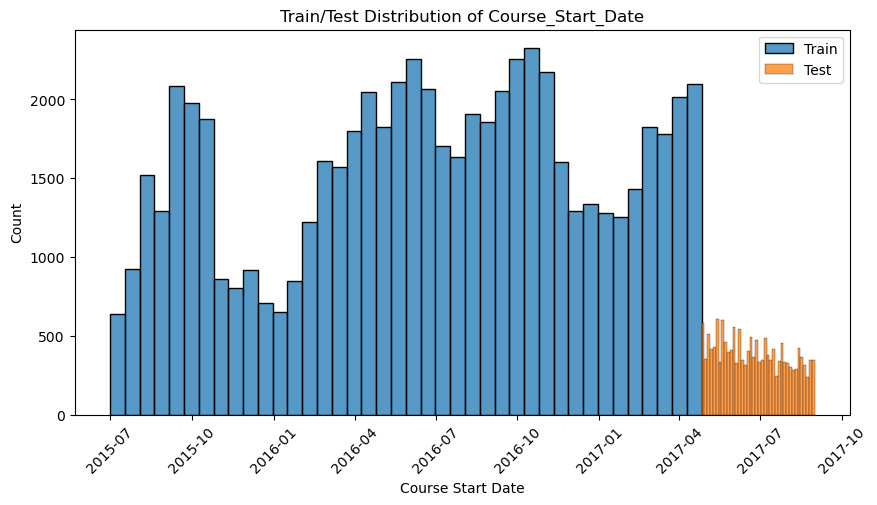

In [383]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df[date_col], label="Train", bins=40, kde=False)
sns.histplot(test_df[date_col], label="Test", bins=40, kde=False)
plt.title("Train/Test Distribution of Course_Start_Date")
plt.xlabel("Course Start Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Date feature insight

The date analysis helps us decide whether time-derived variables should be included in feature engineering.  
If cancellation rates differ by month, weekday, quarter, or time period, then date features may help the model capture seasonal or operational behavior.

The train/test date comparison is also important for validation strategy.  
If the test set comes from a later time period than the train set, we should consider testing a time-aware validation split in addition to random stratified cross-validation.